# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: William Natcharian

**ID**: wrn25

> **Due Date**
>
> Thursday, 10/23/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Desktop/4750 Cloned Repositories/hw3-wrn25-hw3`


In [2]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

--> 

For the equation: 

- $U\frac{dC}{dx} = k_a(C_S-C) - k_cB_0e^{\frac{-k_cx}{U}} - k_nN_0e^{\frac{-k_nx}{U}}$

The Streeter-Phelps Solution is below:

- $C(x) = C_s(1-\alpha _1) + C_0\alpha _1 - B_0\alpha _2 - N_0\alpha _3$

With:

- $\alpha _1 = e^{\frac{-k_ax}{U}}$, 

- $\alpha _2 = (\frac{k_c}{k_a-k_c})[e^{\frac{-k_cx}{U}} - e^{\frac{-k_ax}{U}}]$

- $\alpha _3 = (\frac{k_n}{k_a-k_n})[e^{\frac{-k_nx}{U}}- e^{\frac{-k_ax}{U}}]$

We are given values for the reaeration rate, $k_a$, and the decay rates of CBOD and NBOD, $k_c$ and $k_n$. So we can calculate this equation for $C(x)$ directly.

--> The graph of this analytic solution is below:



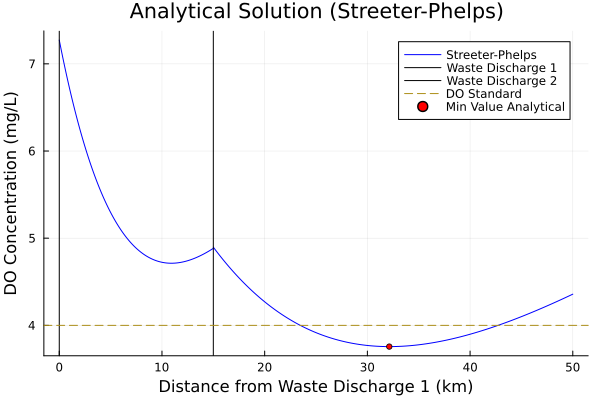

In [39]:
Cs = 10
C01 = 7.273
C02 = 4.897
B01 = 9.091
B02 = 8.735
N01 = 7.723
N02 = 7.838
ka = 0.55
kc = 0.35
kn = 0.25
U = 6

x1 = range(0, 15, length=1000)
x2 = range(15, 50, length=1000)
a1 = exp.(-ka*x1/U)
a2 = (kc/(ka-kc))*(exp.(-kc*x1/U) - exp.(-ka*x1/U))
a3 = (kn/(ka-kn))*(exp.(-kn*x1/U) - exp.(-ka*x1/U))

C1 = Cs*(1 .- a1) + C01*a1 - B01*a2 - N01*a3
C2 = Cs*(1 .- a1) + C02*a1 - B02*a2 - N02*a3

p1 = plot(x1,C1, xlabel = "Distance from Waste Discharge 1 (km)", ylabel = "DO Concentration (mg/L)", 
label = "", color =:blue, title = "Analytical Solution (Streeter-Phelps)")
plot!(p1, x2, C2, label = "Streeter-Phelps", color =:blue)
vline!([0], label = "Waste Discharge 1", color =:black)
vline!([15], label = "Waste Discharge 2", color =:black)
hline!([4], label = "DO Standard", linestyle=:dash)
scatter!(p1, [x2[490]], [3.7562], marker =:circle, markersize =3, color =:red, label = "Min Value Analytical")

#Code to find the minimum value of DO
#min_value = 8.0
#x_value = 0
#for i in 1:1000
    #if C2[i] < min_value
        #min_value = C2[i]
        #x_value = i
    #end
#end
#print(x_value)

--> The figure above shows the dissolved oxygen concentrations in mg/L in the river flow as it moves from 0km to 50km away from the first waste discharge. The second wast discharge is located at 15km. The value of the minimum level of DO is 3.756mg/L at about 32.15km.

--> Code Explanation: I added the governing equations for each alpha variable into my code and had them depend on a large range of x values. I split the x values up into two ranges, for before and after the second waste discharge. To find values for N_0 and B_0 for each discharge condition I used the volumetric concentration equation and the available information in the table, and the values at x = 15km to solve for each value. I added vertical lines using the vline!() function to show clearly where the waste discharges were located. To find the minimum value of the plotted points I used a for loop to iterate over each value and keep the lowest it found (3.756mg/L).

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

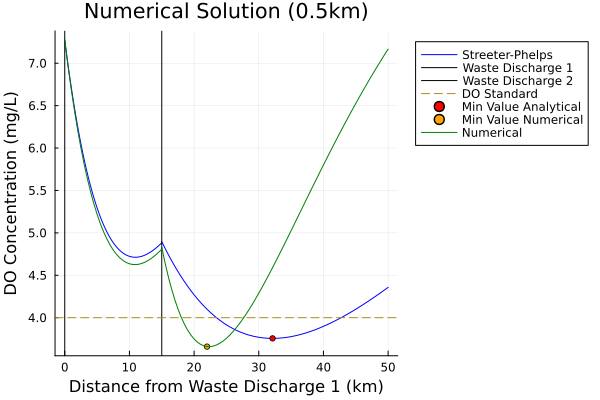

In [40]:
function do_numerical(L, Δx, C0, B0, N0, ka, kn, kc, Cs, U)
    n = Int(L / Δx)
    C = zeros(n + 1)
    B = zeros(n + 1)
    N = zeros(n + 1)
    C[1] = C0
    B[1] = B0
    N[1] = N0
    for i = 1:n
        B[i+1] = B[i] * exp(-kc * Δx / U)
        N[i+1] = N[i] * exp(-kn * Δx / U)
        C[i+1] = C[i] + (Δx / U) * (ka * (Cs - C[i]) - kc * B[i] - kn * N[i])
    end
    return (C, B, N)
end
C1_, B1_, N1_ = do_numerical(15, 0.5, 7.273, 9.091, 7.723, .55, .25, .35, 10, 6)
C2_, B2_, N2_ = do_numerical(35, 0.5, 4.831, 8.735, 7.834, .55, .25, .35, 10, 6)
scatter!(p1, [22], [3.6593], marker =:circle, markersize =3, color =:orange, label = "Min Value Numerical",
title = "Numerical Solution (0.5km)")
plot!(p1, 0:0.5:15, C1_, label = "Numerical", color =:green, legend =:outertopright)
plot!(p1, 15:0.5:50, C2_, label = "", color =:green)
display(p1)

--> The figure above shows the analytical solution (Streeter-Phelps) and the numerical approximation with $\Delta x = 0.5km$ for the dissolved oxygen levels in the river at increasing distance away from the first Waste Discharge. We see that both solutions dip below the DO standard of 4mg/L, and the numerical solution reaches its minimum much earlier.

--> Code Explanation: I used code seen in lecture to model the numerical and adapted it for this problem and with accurate values for variables. I used the plot!() function to add the new plots generated from the do_numerical() function to the same plot from problem 1.1. I used the scatter!() function to add the second minimum value point. To find the initial conditions for the second part of the numerical graph (after 15km), I printed out the important values at x = 15km then solved the volumetric concentration equations to find the slightly altered values for initial conditions from 15km to 50km.

--> The min value has changed to 3.6593mg/L at approximately x = 22km. This minimum is less than what we got in problem 1.1, and it occurs earlier. This is because when we approximate the derivative while a function is decreasing and concave up, we end up overestimating the overall magntiude of the rate of decrease. We can see this in the first section (0km to 15km) where the minimum ends up being slightly less than the analytical solution. This means that we have a smaller value for initial concentration at 15km after the second discharge begins mixing with the flow. In addition, the vlaues for B0 and N0 for after Waste discharge 2 are slightly different than they were in the analytical solution. All of this leads to a quicker decrease of DO, and eventually a faster recovery since the reaerationr ate also increases faster as it depends on the difference between the saturation concentration and the current concentration.

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

Min_value: 4.200005378605605, X_value = 33.04304304304304, Proportion = 0.7239800000012562


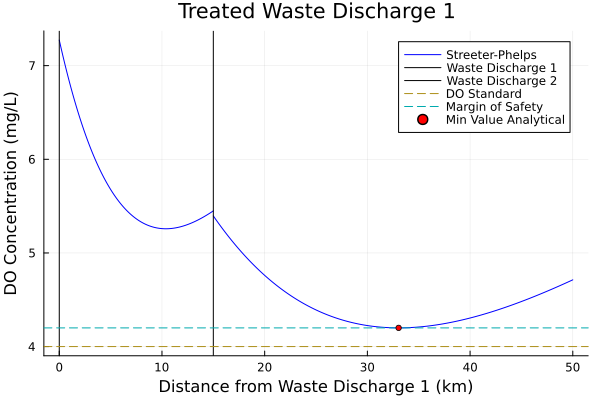

In [45]:
#Treating Waste Discharge 1
found = false
proportion = 1
while found == false
    Cs = 10
    ka = 0.55
    kc = 0.35
    kn = 0.25
    U = 6

    C01 = 7.273 #doesn't change
    C02 = 4.897 # will change later

    B01 = (5*100 + 50*10*proportion)/110 #previously 9.091
    B02 = ((B01*exp(-kc*15/U))*110 + 15*(45))/125 #previously 8.735

    N01 = (5*100 + 35*10*proportion)/110 #previously 7.723
    N02 = ((N01*exp(-kn*15/U))*110 + 15*(35))/125#previously 7.838

    x1 = range(0, 15, length=1000)
    x2 = range(15, 50, length=1000)
    a1 = exp.(-ka*x1/U)
    a2 = (kc/(ka-kc))*(exp.(-kc*x1/U) - exp.(-ka*x1/U))
    a3 = (kn/(ka-kn))*(exp.(-kn*x1/U) - exp.(-ka*x1/U))

    C1 = Cs*(1 .- a1) + C01*a1 - B01*a2 - N01*a3
    C02 = ((C1[1000]*110) + 5*(15))/125 #previously 4.897
    C2 = Cs*(1 .- a1) + C02*a1 - B02*a2 - N02*a3

    x_value = 0
    min_value = 8.0
    for i in 1:1000
        if C2[i] < min_value
            min_value = C2[i]
            x_value = i
        end
    end
    if min_value > 4.2
        found = true
    else
        proportion = proportion - 0.00001
    end
end
x_pos = x2[x_value]
println("Min_value: $min_value, X_value = $x_pos, Proportion = $proportion")

p3 = plot(x1,C1, xlabel = "Distance from Waste Discharge 1 (km)", ylabel = "DO Concentration (mg/L)", 
label = "", color =:blue, title = "Treated Waste Discharge 1")
plot!(p3, x2, C2, label = "Streeter-Phelps", color =:blue)
vline!([0], label = "Waste Discharge 1", color =:black)
vline!([15], label = "Waste Discharge 2", color =:black)
hline!([4], label = "DO Standard", linestyle=:dash)
hline!([4.2], label = "Margin of Safety", linestyle=:dash)
scatter!(p3, [x2[x_value]], [min_value], marker =:circle, markersize =3, color =:red, label = "Min Value Analytical")

display(p3)

--> The figure above shows the analytical solution for dissolved oxygen levels as we move away from Waste Discharge 1, after decreasing the initial CBOD and NBOD levels coming out of Waste Discharge 1. The CBOD and NBOD levels were scaled down by a proportion of 0.724, to achieve a minimum DO level above 4.2mg/L (standard with 5% margin of safety).

--> Code explanation: I used a while loop to solve for the minimum value of the whole system while decreasing the initial levels of CBOD and NBOD by the same level. I used the volumetric concentrations several times to be able to find the initial levels and the levels at x = 15km to accurately be able to create a graph of the new plot, to double check the results. I used the same equations as in problem 1.1 to solve the system analytically.

- Minimum level of treatment for Waste Discharge 1 = 27.61%, 

- Which achieves a minimum value of 4.20mg/L 

- At about x = 33.04km

Min_value: 4.200011453673051, X_value = 29.32932932932933, Proportion = 0.7830000000009876


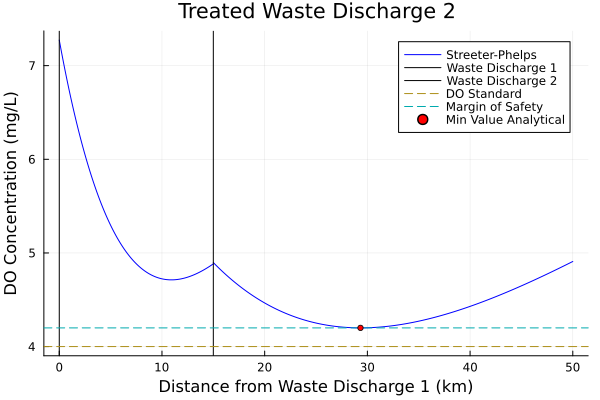

In [49]:
#Treating Waste Discharge 2
found = false
proportion = 1
while found == false
    Cs = 10
    ka = 0.55
    kc = 0.35
    kn = 0.25
    U = 6

    C01 = 7.273 #doesn't change
    #C02 = 4.897 # will change later

    B01 = 9.091 #previously (5*100 + 50*10*proportion)/110
    B02 = ((B01*exp(-kc*15/U))*110 + 15*(45*proportion))/125 #previously 8.735

    N01 = 7.723
    N02 = ((N01*exp(-kn*15/U))*110 + 15*(35*proportion))/125 #previously 7.838

    x1 = range(0, 15, length=1000)
    x2 = range(15, 50, length=1000)
    a1 = exp.(-ka*x1/U)
    a2 = (kc/(ka-kc))*(exp.(-kc*x1/U) - exp.(-ka*x1/U))
    a3 = (kn/(ka-kn))*(exp.(-kn*x1/U) - exp.(-ka*x1/U))

    C1 = Cs*(1 .- a1) + C01*a1 - B01*a2 - N01*a3
    C02 = ((C1[1000]*110) + 5*(15))/125 #previously 4.897
    C2 = Cs*(1 .- a1) + C02*a1 - B02*a2 - N02*a3

    x_value = 0
    min_value = 8.0
    for i in 1:1000
        if C2[i] < min_value
            min_value = C2[i]
            x_value = i
        end
    end
    if min_value > 4.2
        found = true
    else
        proportion = proportion - 0.00001
    end
end
x_pos = x2[x_value]
println("Min_value: $min_value, X_value = $x_pos, Proportion = $proportion")

p4 = plot(x1,C1, xlabel = "Distance from Waste Discharge 1 (km)", ylabel = "DO Concentration (mg/L)", 
label = "", color =:blue, title = "Treated Waste Discharge 2")
plot!(p4, x2, C2, label = "Streeter-Phelps", color =:blue)
vline!([0], label = "Waste Discharge 1", color =:black)
vline!([15], label = "Waste Discharge 2", color =:black)
hline!([4], label = "DO Standard", linestyle=:dash)
hline!([4.2], label = "Margin of Safety", linestyle=:dash)
scatter!(p4, [x2[x_value]], [min_value], marker =:circle, markersize =3, color =:red, label = "Min Value Analytical")

display(p4)

--> The figure above shows the analytical solution for dissolved oxygen levels as we move away from Waste Discharge 1, after decreasing the initial CBOD and NBOD levels coming out of Waste Discharge 2. The CBOD and NBOD levels were scaled down by a proportion of 0.783, to achieve a minimum DO level above 4.2mg/L (standard with 5% margin of safety).

--> Code explanation: I used the same process for both Waste Discharge treatments, only changing the equations for B01, B02, N01, and N02 accordingly: I used a while loop to solve for the minimum value of the whole system while decreasing the initial levels of CBOD and NBOD by the same level. I used the volumetric concentrations several times to be able to find the initial levels and the levels at x = 15km to accurately be able to create a graph of the new plot, to double check the results. I used the same equations as in problem 1.1 to solve the system analytically.

- Minimum level of treatment for Waste Discharge 2 = 22.70%, 

- Which achieves a minimum value of 4.20mg/L 

- At about x = 29.33km

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

--> It would be logistically difficult and more expensive to require both Waste Discharges to treat their streams equally, so I would likely opt to treat waste stream 2 alone. From my analysis in problem 1.3, we only need to treat Waste Discharge 2 by 22.70% for us to meet the DO Standard with a margin of safety of 5%. Treating the stream by this amount seems very plausible to achieve for one treatment center, and there seems to be little benefit in splitting that treatment between the two streams.

--> If new information comes to light that treating the waste by 10% is very easy and cheap for both streams, while treating one stream by 20% or more becomes incredibly difficult and exponentially expensive, then treating them equally would become the clearly better option to go with.

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

In [ ]:
#Setting a seed for this simulation
Random.seed!(1)

TaskLocalRNG()

Final mean: 2.15, 
Final 95% Confidence Interval: [1.8294957839447918, 2.470504216055208]


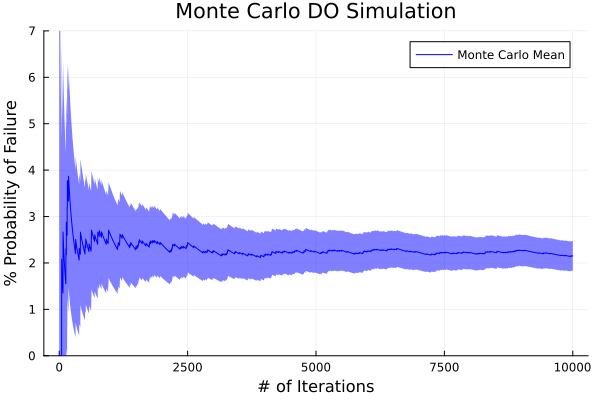

In [74]:
#Monte Carlo Simulation
log_dist = LogNormal(2.0, 0.15)
log_sample = rand(log_dist, 10000)

proportion = 0.72398
Cs = 10
ka = 0.55
kc = 0.35
kn = 0.25
U = 6

each_prob = zeros(Float64, 10000)
total_prob = zeros(Float64, 10000)

for i in 1:10000

    C01 = log_sample[i] #changes based on lognormal

    B01 = (5*100 + 50*10*proportion)/110 #previously 9.091
    B02 = ((B01*exp(-kc*15/U))*110 + 15*(45))/125 #previously 8.735

    N01 = (5*100 + 35*10*proportion)/110 #previously 7.723
    N02 = ((N01*exp(-kn*15/U))*110 + 15*(35))/125#previously 7.838

    x1 = range(0, 15, length=10000)
    x2 = range(15, 50, length=10000)
    a1 = exp.(-ka*x1/U)
    a2 = (kc/(ka-kc))*(exp.(-kc*x1/U) - exp.(-ka*x1/U))
    a3 = (kn/(ka-kn))*(exp.(-kn*x1/U) - exp.(-ka*x1/U))

    C1 = Cs*(1 .- a1) + C01*a1 - B01*a2 - N01*a3
    C02 = ((C1[10000]*110) + 5*(15))/125 #previously 4.897
    C2 = Cs*(1 .- a1) + C02*a1 - B02*a2 - N02*a3

    x_value = 0
    min_value = 8.0
    for v in 1:10000
        if C2[v] < min_value
            min_value = C2[v]
            x_value = v
        end
    end

    if min_value < 4.0
        each_prob[i] = 1
    else
        each_prob[i] = 0
    end

end

counter = 0
mean = 0
for f in 1:10000
    counter = counter + each_prob[f]
    mean = counter / f
    total_prob[f] = mean*100
end

final_mean_unscaled = mean
final_mean = mean*100

Standard_error = 1.1274
scaling = sqrt(final_mean_unscaled*(1-final_mean_unscaled))
n = zeros(Float64, 10000)
for g in 1:10000
    n[g] = 1.96*scaling*100*1.1274 / sqrt(g)
end
p5 = plot(1:10000,total_prob, xlabel = "# of Iterations", ylabel = "% Probability of Failure", 
label = "Monte Carlo Mean", color =:blue, title = "Monte Carlo DO Simulation",
ribbon = n)
ylims!((0, 7))

CI_low = final_mean - n[10000]
CI_high = final_mean + n[10000]

println("Final mean: $final_mean, \nFinal 95% Confidence Interval: [$CI_low, $CI_high]")
display(p5)

--> The plot above shows a Monte Carlo Simulation for the probability that the DO levels in the streams dip below the 4mg/L standard as the initial DO levels of the stream vary according to a Log Normal distribution.

- The final mean value for the probability of failure is: 2.15%

- The 95% confidence interval for that value is [1.83%, 2.47%]

- This means that if we were to run this exact experiment an infinite amount of times, approximately 95% of the simulations would show a final mean within the confidence interval above.

--> Explanation of code: I used the same equations as in previous parts of this homework to solve for if the given initial DO concentrations led to a minimum value less than 4mg/L. Every time a failure was recorded a 1 was added to an array, otherwise a 0. Then I calculated the running mean at each iteration and the corresponding CI interval size. I then plotted the results and created the CI with a ribbon command.

--> I decided that my Monte Carlo sample size was sufficiently large once it started taking more than 10 seconds to generate the plot. At that point, increasing the sample size would take way longer to generate than it is worth it in terms of the final accuracy it improves.

## References

List any external references consulted, including classmates.

--> I used no references and worked alone.